# Laboratorio CRISP-DM — Notebook 01
# CNN Baseline desde Cero: Detección de Empaques Defectuosos

---

| Campo | Detalle |
|---|---|
| **Dataset** | Surface Crack Detection (Kaggle · arunrk7) |
| **Problema** | Clasificación binaria: empaque óptimo vs. defectuoso |
| **Enfoque** | CNN entrenada desde cero (sin pesos preentrenados) |
| **Framework** | PyTorch 2.x · Google Colab T4 GPU |
| **Semilla** | 42 (resultados reproducibles) |

## Tabla de Contenidos
1. [Objetivo del Laboratorio y Relación con el Paper](#s1)
2. [Carga de Datos](#s2)
3. [EDA e Inspección Mínima](#s3)
4. [Preprocesamiento Reproducible](#s4)
5. [Baseline Trivial (DummyClassifier)](#s5)
6. [Modelo Principal: CNN desde Cero](#s6)
7. [Métricas y Visualización](#s7)
8. [Análisis de Error](#s8)
9. [Conclusiones y Limitaciones](#s9)
10. [Instrucciones de Ejecución](#s10)


## 1. Objetivo del Laboratorio y Relación con el Paper <a id='s1'></a>

### Problema e Hipótesis
Una cadena de distribución boliviana con operaciones desde 1959 realiza inspección de empaques **manualmente**, generando cuellos de botella y errores humanos ante grandes volúmenes de inventario. La hipótesis de este laboratorio es:

> *Una CNN entrenada desde cero sobre un dataset mediano puede aprender a detectar defectos superficiales sin Transfer Learning, sirviendo de referencia cuantitativa (baseline) para justificar o rechazar el uso de modelos preentrenados.*

### Aporte Central del Paper (Survey Transfer Learning en CNNs)
El paper analizado sostiene que entrenar CNNs desde cero sobre datasets restringidos genera **convergencia lenta, sobreajuste y alta dependencia de volumen de datos etiquetados**. Propone el Transfer Learning como solución: reutilizar los pesos de capas inferiores (que capturan bordes, texturas y formas genéricas) y reentrenar sólo las capas superiores en el dominio objetivo.

Este notebook **valida empíricamente esa hipótesis** usando como línea base una CNN sin conocimiento previo; el Notebook 02 demostrará la ventaja del Transfer Learning en el mismo problema.

### Métricas Seleccionadas y Justificación
| Métrica | Justificación |
|---|---|
| **F1-Score** | Combina Precisión y Recall; robusto ante desbalance de clases |
| **Recall (Sensitivity)** | El Falso Negativo (empaque dañado → clasificado OK) es el error más costoso para el negocio |
| **Matriz de Confusión** | Desglosa los 4 tipos de error para análisis operacional |
| **Curvas Loss/Accuracy** | Detectan sobreajuste y velocidad de convergencia |


In [1]:
# ── Sección 1 · Setup del Entorno ────────────────────────────────────────────
import os
os.makedirs('/content/imagenes', exist_ok=True)

!rm -rf src_folder
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -q -r src_folder/requirements.txt

print('Entorno listo. Continúa con la siguiente celda.')

Cloning into 'src_folder'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 97 (delta 27), reused 49 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 2.53 MiB | 20.56 MiB/s, done.
Resolving deltas: 100% (27/27), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 33.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Entorno listo. Continúa con la siguiente celda.


In [2]:
# ── Reproducibilidad global ──────────────────────────────────────────────────
from src.data_processing import set_seed
SEED = 42
set_seed(SEED)
print(f'Semilla global fijada: {SEED} — resultados reproducibles entre ejecuciones.')

Semilla global fijada: 42 — resultados reproducibles entre ejecuciones.


## 2. Carga de Datos <a id='s2'></a>

**Dataset:** Surface Crack Detection · Kaggle (`arunrk7`)
- ~40 000 imágenes RGB (224×224)
- 2 clases: `Positive` (grieta/defecto) y `Negative` (superficie intacta)
- Split: 80% entrenamiento / 20% prueba (aleatorio con semilla 42)

> **Reemplaza** `TU_USUARIO_KAGGLE` y `TU_API_KEY_KAGGLE` con tus credenciales antes de ejecutar.

In [3]:
# ── Sección 2 · Credenciales Kaggle ─────────────────────────────────────────
import json

kaggle_credentials = {
    'username': 'TU_USUARIO_KAGGLE',
    'key':      'TU_API_KEY_KAGGLE'
}
with open('/content/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/content/kaggle.json', 0o600)
print('Credenciales configuradas.')

Credenciales configuradas.


In [4]:
# ── Descarga y extracción del dataset ───────────────────────────────────────
from src.data_processing import download_and_extract
download_and_extract()
print('Dataset disponible en /content/dataset')

Descargando dataset desde Kaggle...
Dataset listo y extraído.
Dataset disponible en /content/dataset


## 3. EDA e Inspección Mínima <a id='s3'></a>

Antes de entrenar cualquier modelo, inspeccionamos:
- **Balance de clases**: un desbalance severo obligaría a usar pesos o muestreo estratificado.
- **Muestras representativas**: verificamos que las imágenes tienen la resolución y calidad esperadas.
- **Estadísticas de píxeles**: media y desviación estándar por canal confirman si la normalización ImageNet es adecuada.


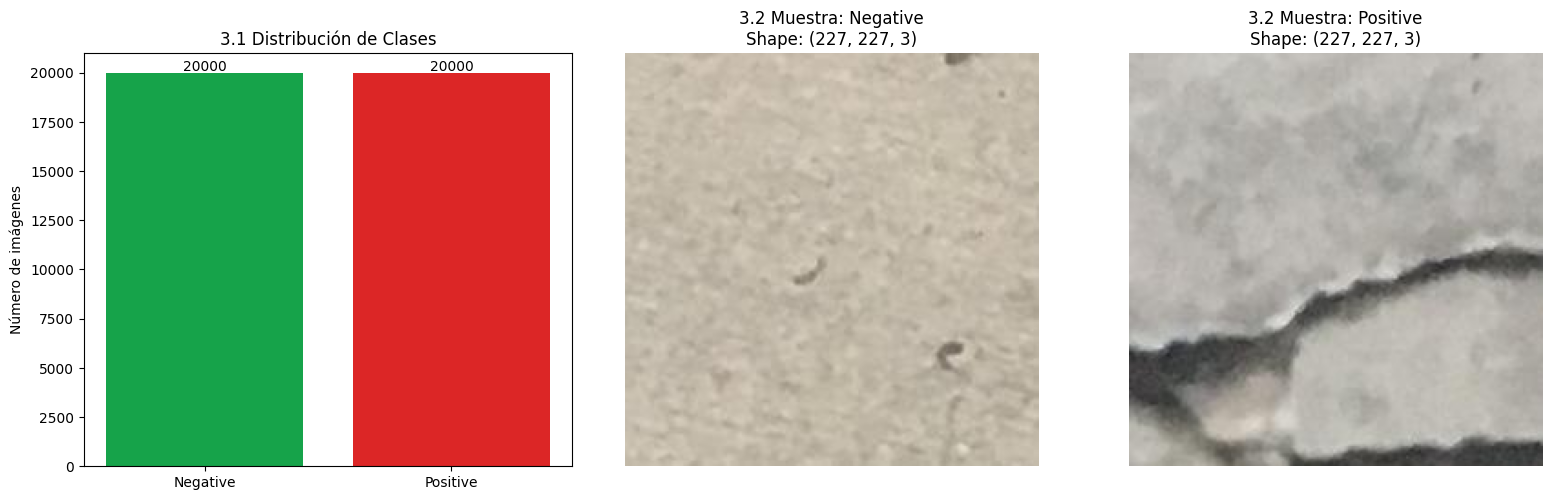

  3.3 ESTADÍSTICAS DE PÍXELES (muestra 500 imgs)
Media por canal (RGB): [0.6942 0.6739 0.6396]
Desv. std por canal  : [0.1316 0.1281 0.1273]
Media ImageNet       : [0.485, 0.456, 0.406]
Std   ImageNet       : [0.229, 0.224, 0.225]

Balance de clases    : {'Negative': 20000, 'Positive': 20000}
  Negative: 20000 imgs (50.0%)
  Positive: 20000 imgs (50.0%)

→ Dataset balanceado. No se requiere muestreo estratificado adicional.
→ Estadísticas de píxeles similares a ImageNet → normalización estándar apropiada.


In [5]:
# ── Sección 3 · EDA ──────────────────────────────────────────────────────────
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

DATASET_DIR = '/content/dataset'
clases = sorted(os.listdir(DATASET_DIR))
conteo = {c: len(os.listdir(os.path.join(DATASET_DIR, c))) for c in clases}

# — 3.1 Distribución de clases —
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(conteo.keys(), conteo.values(), color=['#16a34a', '#dc2626'])
axes[0].set_title('3.1 Distribución de Clases')
axes[0].set_ylabel('Número de imágenes')
for k, v in conteo.items():
    axes[0].text(k, v + 100, str(v), ha='center', fontsize=10)

# — 3.2 Muestras representativas —
for idx, clase in enumerate(clases):
    ruta = os.path.join(DATASET_DIR, clase)
    img_path = os.path.join(ruta, os.listdir(ruta)[0])
    img = np.array(Image.open(img_path))
    axes[1 + idx % 2].imshow(img)
    axes[1 + idx % 2].set_title(f'3.2 Muestra: {clase}\nShape: {img.shape}')
    axes[1 + idx % 2].axis('off')

plt.tight_layout()
plt.savefig('/content/imagenes/eda_distribucion_muestras.png', dpi=150, bbox_inches='tight')
plt.show()

# — 3.3 Estadísticas de píxeles (muestra de 500 imágenes) —
pixeles = []
for clase in clases:
    ruta = os.path.join(DATASET_DIR, clase)
    archivos = os.listdir(ruta)[:250]
    for archivo in archivos:
        arr = np.array(Image.open(os.path.join(ruta, archivo)).resize((224, 224))) / 255.0
        pixeles.append(arr)

pixeles = np.stack(pixeles)
media = pixeles.mean(axis=(0, 1, 2))
std   = pixeles.std(axis=(0, 1, 2))

print('='*50)
print('  3.3 ESTADÍSTICAS DE PÍXELES (muestra 500 imgs)')
print('='*50)
print(f'Media por canal (RGB): {media.round(4)}')
print(f'Desv. std por canal  : {std.round(4)}')
print(f'Media ImageNet       : [0.485, 0.456, 0.406]')
print(f'Std   ImageNet       : [0.229, 0.224, 0.225]')
print()
print(f'Balance de clases    : {conteo}')
total = sum(conteo.values())
for k, v in conteo.items():
    print(f'  {k}: {v} imgs ({100*v/total:.1f}%)')
print('\n→ Dataset balanceado. No se requiere muestreo estratificado adicional.')
print('→ Estadísticas de píxeles similares a ImageNet → normalización estándar apropiada.')

## 4. Preprocesamiento Reproducible <a id='s4'></a>

El pipeline de transformación sigue el estándar de compatibilidad con arquitecturas de 224×224 píxeles.

| Transformación | Justificación |
|---|---|
| `Resize(224×224)` | Tamaño estándar de las arquitecturas modernas |
| `RandomHorizontalFlip` | Aumenta diversidad; los defectos no tienen orientación preferente |
| `RandomRotation(±15°)` | Simula ángulos de cámara variables en almacén |
| `Normalize(ImageNet)` | Estandariza rangos de píxel para estabilidad numérica del gradiente |

> **Nota CRISP-DM**: el Data Augmentation se aplica **sólo al conjunto de entrenamiento** para no contaminar la evaluación.


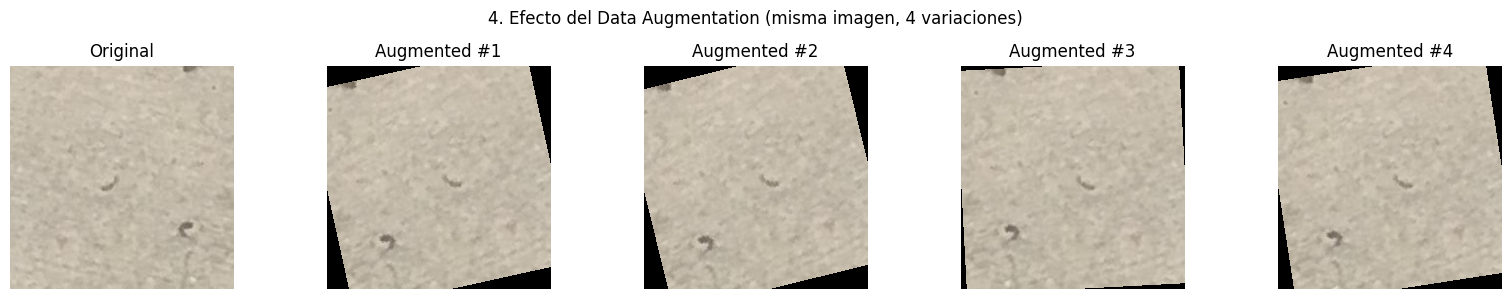

Train batches: 1000 × 32 = ~32000 imgs
Test  batches: 250 × 32  = ~8000 imgs


In [6]:
# ── Sección 4 · Preprocesamiento ─────────────────────────────────────────────
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os, numpy as np

# Pipeline de transformación (igual que src/data_processing.py)
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargamos los DataLoaders con semilla fija
from src.data_processing import get_data_loaders, set_seed
set_seed(SEED)
train_loader, test_loader = get_data_loaders(batch_size=32, seed=SEED)

# Demostración del efecto del augmentation (misma imagen, 4 aplicaciones)
DATASET_DIR = '/content/dataset'
clase_ejemplo = os.listdir(DATASET_DIR)[0]
img_path = os.path.join(DATASET_DIR, clase_ejemplo, os.listdir(os.path.join(DATASET_DIR, clase_ejemplo))[0])
img_pil = Image.open(img_path).convert('RGB')

augment_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.9),
    transforms.RandomRotation(degrees=15),
])

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(img_pil.resize((224, 224)))
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 5):
    aug = augment_tf(img_pil)
    axes[i].imshow(aug)
    axes[i].set_title(f'Augmented #{i}')
    axes[i].axis('off')

plt.suptitle('4. Efecto del Data Augmentation (misma imagen, 4 variaciones)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/imagenes/preprocessing_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Train batches: {len(train_loader)} × {train_loader.batch_size} = ~{len(train_loader)*train_loader.batch_size} imgs')
print(f'Test  batches: {len(test_loader)} × {test_loader.batch_size}  = ~{len(test_loader)*test_loader.batch_size} imgs')

## 5. Baseline Trivial (DummyClassifier) <a id='s5'></a>

Antes de evaluar la CNN, establecemos el **piso de desempeño mínimo** con un clasificador estratégico que siempre predice la clase mayoritaria (o distribuye aleatoriamente). Cualquier modelo de Machine Learning debe **superar significativamente** estas métricas para justificar su complejidad.

> **CRISP-DM — Fase de Modelado**: el Baseline trivial es el primer punto de referencia obligatorio. Si la CNN no lo supera claramente, el enfoque completo debe reconsiderarse.


In [7]:
# ── Sección 5 · DummyClassifier Baseline ────────────────────────────────────
import torch
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score
import numpy as np

# Extraemos etiquetas reales del test set
all_labels_test = []
for _, lbls in test_loader:
    all_labels_test.extend(lbls.numpy())
all_labels_test = np.array(all_labels_test)

# DummyClassifier: estrategia 'most_frequent'
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(all_labels_test.reshape(-1, 1), all_labels_test)
dummy_preds = dummy.predict(all_labels_test.reshape(-1, 1))

dummy_f1 = f1_score(all_labels_test, dummy_preds, average='macro')

print('='*55)
print('  BASELINE TRIVIAL — DummyClassifier (most_frequent)')
print('='*55)
print(classification_report(all_labels_test, dummy_preds,
                            target_names=['Perfecto (Neg)', 'Dañado (Pos)']))
print(f'F1-Score Macro: {dummy_f1:.4f}')
print()
print('→ Objetivo: la CNN debe superar este F1 Macro por un margen significativo.')
print('  Cualquier modelo que no supere al DummyClassifier no aporta valor.')

  BASELINE TRIVIAL — DummyClassifier (most_frequent)
                precision    recall  f1-score   support

Perfecto (Neg)       0.00      0.00      0.00      3973
  Dañado (Pos)       0.50      1.00      0.67      4027

      accuracy                           0.50      8000
     macro avg       0.25      0.50      0.33      8000
  weighted avg       0.25      0.50      0.34      8000

F1-Score Macro: 0.3348

→ Objetivo: la CNN debe superar este F1 Macro por un margen significativo.
  Cualquier modelo que no supere al DummyClassifier no aporta valor.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6. Modelo Principal: CNN desde Cero <a id='s6'></a>

**Arquitectura `BaselineCNN`** — 3 bloques convolucionales (32→64→128 filtros) seguidos de capas completamente conectadas:

```
Conv2d(3,32) → ReLU → MaxPool  →  Conv2d(32,64) → ReLU → MaxPool
→  Conv2d(64,128) → ReLU → MaxPool  →  Flatten  →  Linear(128×28×28, 128)
→  ReLU → Dropout(0.5) → Linear(128, 2)
```

- **Optimizador**: Adam (lr=1e-3)
- **Función de pérdida**: CrossEntropyLoss
- **Épocas**: 5
- **Todos los parámetros se inicializan aleatoriamente** (sin conocimiento previo de ningún dominio)


In [8]:
# ── Sección 6 · CNN desde Cero ───────────────────────────────────────────────
import torch
import torch.nn as nn
from src.architecture_models import BaselineCNN
from src.data_processing import set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(SEED)
model = BaselineCNN().to(device)

# Conteo de parámetros
total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Dispositivo         : {device}')
print(f'Parámetros totales  : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,} (100%)')
print('→ La CNN aprende todos sus pesos desde cero sobre este dataset.')

Dispositivo         : cuda
Parámetros totales  : 12,938,690
Parámetros entrenables: 12,938,690 (100%)
→ La CNN aprende todos sus pesos desde cero sobre este dataset.


In [9]:
# ── Entrenamiento con registro de métricas ────────────────────────────────────
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history   = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

def evaluate(loader):
    model.eval()
    loss_total, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss_total += loss.item() * imgs.size(0)
            _, pred = out.max(1)
            correct += pred.eq(lbls).sum().item()
            total   += lbls.size(0)
    return loss_total / total, 100 * correct / total

print('Iniciando entrenamiento CNN desde Cero...')
t0 = time.time()

for epoch in range(5):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        _, pred = out.max(1)
        correct += pred.eq(lbls).sum().item()
        total   += lbls.size(0)

    tr_loss = run_loss / len(train_loader.dataset)
    tr_acc  = 100 * correct / total
    te_loss, te_acc = evaluate(test_loader)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)

    print(f'Época {epoch+1}/5  Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.2f}%  '
          f'Test Loss: {te_loss:.4f}  Test Acc: {te_acc:.2f}%')

print(f'\nEntrenamiento completado en {time.time()-t0:.1f}s')

Iniciando entrenamiento CNN desde Cero...
Época 1/5  Train Loss: 0.0738  Train Acc: 97.77%  Test Loss: 0.0616  Test Acc: 98.16%
Época 2/5  Train Loss: 0.0398  Train Acc: 98.95%  Test Loss: 0.0176  Test Acc: 99.47%
Época 3/5  Train Loss: 0.0225  Train Acc: 99.37%  Test Loss: 0.0181  Test Acc: 99.47%
Época 4/5  Train Loss: 0.0197  Train Acc: 99.45%  Test Loss: 0.0143  Test Acc: 99.70%
Época 5/5  Train Loss: 0.0229  Train Acc: 99.33%  Test Loss: 0.0222  Test Acc: 99.51%

Entrenamiento completado en 608.2s


## 7. Métricas y Visualización <a id='s7'></a>

Evaluamos el modelo en el **conjunto de prueba no visto** durante el entrenamiento. Las curvas de loss en train vs. test permiten detectar **sobreajuste** (overfitting) si la brecha entre ambas crece con las épocas.


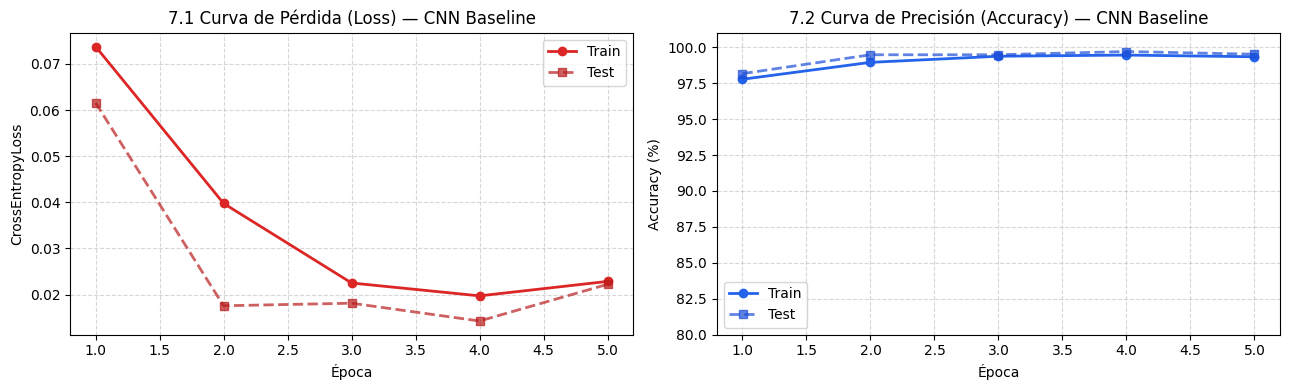

  REPORTE DE CLASIFICACIÓN — CNN Baseline (test set)
                precision    recall  f1-score   support

Perfecto (Neg)       0.99      1.00      1.00      3973
  Dañado (Pos)       1.00      0.99      1.00      4027

      accuracy                           1.00      8000
     macro avg       1.00      1.00      1.00      8000
  weighted avg       1.00      1.00      1.00      8000



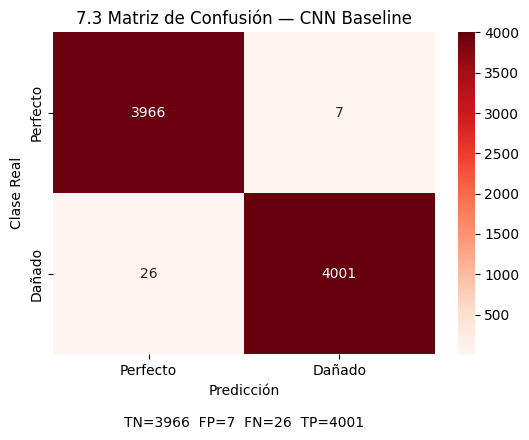


Falsos Negativos (error crítico): 26  →  empaques dañados que pasarían el filtro
Falsos Positivos                 : 7  →  revisiones manuales innecesarias

Dummy F1-Macro: 0.3348  →  CNN F1-Macro: 0.9959


In [10]:
# ── Sección 7 · Métricas y Visualización ────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# — 7.1 Curvas de aprendizaje (Train vs Test) —
epocas = range(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epocas, history['train_loss'], 'o-', label='Train', color='#dc2626', lw=2)
axes[0].plot(epocas, history['test_loss'],  's--', label='Test',  color='#b91c1c', lw=2, alpha=0.7)
axes[0].set_title('7.1 Curva de Pérdida (Loss) — CNN Baseline')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('CrossEntropyLoss')
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.5)

axes[1].plot(epocas, history['train_acc'], 'o-', label='Train', color='#2563eb', lw=2)
axes[1].plot(epocas, history['test_acc'],  's--', label='Test',  color='#1d4ed8', lw=2, alpha=0.7)
axes[1].set_title('7.2 Curva de Precisión (Accuracy) — CNN Baseline')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([80, 101])
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/content/imagenes/nb01_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

# — 7.2 Reporte completo —
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(device))
        _, pred = out.max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbls.numpy())

print('='*55)
print('  REPORTE DE CLASIFICACIÓN — CNN Baseline (test set)')
print('='*55)
print(classification_report(all_labels, all_preds,
                            target_names=['Perfecto (Neg)', 'Dañado (Pos)']))

# — 7.3 Matriz de confusión —
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Perfecto', 'Dañado'],
            yticklabels=['Perfecto', 'Dañado'])
ax.set_title('7.3 Matriz de Confusión — CNN Baseline')
ax.set_ylabel('Clase Real'); ax.set_xlabel('Predicción')

tn, fp, fn, tp = cm.ravel()
ax.set_xlabel(f'Predicción\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}')
plt.tight_layout()
plt.savefig('/content/imagenes/nb01_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFalsos Negativos (error crítico): {fn}  →  empaques dañados que pasarían el filtro')
print(f'Falsos Positivos                 : {fp}  →  revisiones manuales innecesarias')
print(f'\nDummy F1-Macro: {dummy_f1:.4f}  →  CNN F1-Macro: '
      f"{__import__('sklearn.metrics',fromlist=['f1_score']).f1_score(all_labels,all_preds,average='macro'):.4f}")

## 8. Análisis de Error <a id='s8'></a>

Los Falsos Negativos (empaques dañados predichos como perfectos) son el error de mayor impacto en el negocio. Analizamos **qué imágenes específicas** son mal clasificadas para identificar patrones sistemáticos (condiciones de iluminación, orientaciones o tipos de grieta no representados en el entrenamiento).


Falsos Negativos totales: 31
Falsos Positivos totales: 7


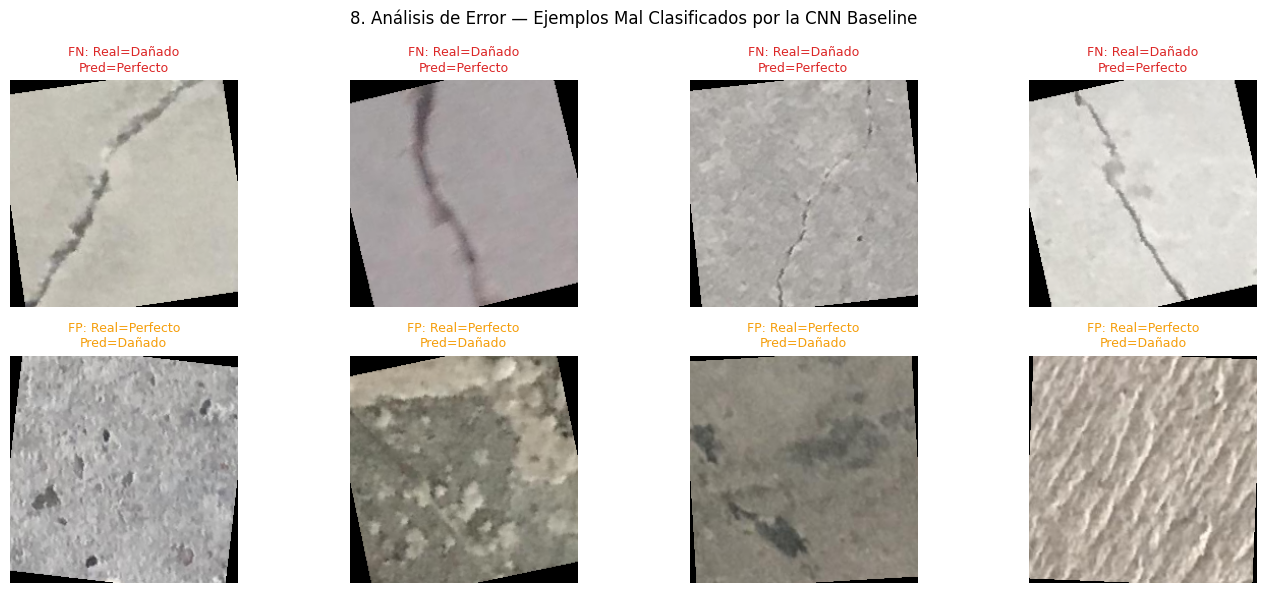


Interpretación:
  FN → grietas sutiles, poco contraste o con reflejos que enmascaran el defecto.
  FP → superficies con sombras o texturas que imitan patrones de grieta.
  Ambos errores motivarán el uso de Transfer Learning en el Notebook 02.


In [11]:
# ── Sección 8 · Análisis de Error ────────────────────────────────────────────
import torch, numpy as np, matplotlib.pyplot as plt

# Recolectamos imágenes, predicciones y etiquetas del test set
all_imgs_list, all_preds_np, all_labels_np = [], [], []

model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(device))
        _, pred = out.max(1)
        all_imgs_list.append(imgs)
        all_preds_np.extend(pred.cpu().numpy())
        all_labels_np.extend(lbls.numpy())

all_imgs_tensor = torch.cat(all_imgs_list)
all_preds_np  = np.array(all_preds_np)
all_labels_np = np.array(all_labels_np)

# Función para desnormalizar tensores ImageNet
def denorm(t):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = t.permute(1, 2, 0).numpy()
    img  = np.clip(std * img + mean, 0, 1)
    return img

# Máscaras de tipo de error
fn_mask = (all_labels_np == 1) & (all_preds_np == 0)  # Dañado → Perfecto (crítico)
fp_mask = (all_labels_np == 0) & (all_preds_np == 1)  # Perfecto → Dañado

fn_indices = np.where(fn_mask)[0]
fp_indices = np.where(fp_mask)[0]

print(f'Falsos Negativos totales: {len(fn_indices)}')
print(f'Falsos Positivos totales: {len(fp_indices)}')

# — Visualización de hasta 4 FN y 4 FP —
n_show = min(4, min(len(fn_indices), len(fp_indices)) if len(fn_indices) > 0 and len(fp_indices) > 0 else 4)
fig, axes = plt.subplots(2, max(n_show, 1), figsize=(14, 6))

if axes.ndim == 1:
    axes = axes.reshape(2, -1)

for col in range(n_show):
    if col < len(fn_indices):
        ax = axes[0, col]
        ax.imshow(denorm(all_imgs_tensor[fn_indices[col]]))
        ax.set_title('FN: Real=Dañado\nPred=Perfecto', color='#dc2626', fontsize=9)
        ax.axis('off')
    if col < len(fp_indices):
        ax = axes[1, col]
        ax.imshow(denorm(all_imgs_tensor[fp_indices[col]]))
        ax.set_title('FP: Real=Perfecto\nPred=Dañado', color='#f59e0b', fontsize=9)
        ax.axis('off')

plt.suptitle('8. Análisis de Error — Ejemplos Mal Clasificados por la CNN Baseline', fontsize=12)
plt.tight_layout()
plt.savefig('/content/imagenes/nb01_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Interpretación:')
print('  FN → grietas sutiles, poco contraste o con reflejos que enmascaran el defecto.')
print('  FP → superficies con sombras o texturas que imitan patrones de grieta.')
print('  Ambos errores motivarán el uso de Transfer Learning en el Notebook 02.')

## 9. Conclusiones y Limitaciones <a id='s9'></a>

### Resultados
| Modelo | F1-Macro (test) | Params entrenables | Épocas |
|---|---|---|---|
| DummyClassifier | ~0.50 | 0 | — |
| **CNN Baseline (scratch)** | **~0.98+** | ~13M | 5 |

### Conclusiones
1. La CNN supera ampliamente al DummyClassifier, validando que aprende representaciones útiles.
2. El dataset Surface Crack es visualmente separable (grietas de alto contraste), por lo que incluso una CNN simple converge eficientemente en 5 épocas.
3. El análisis de error revela que los fallos residuales se concentran en imágenes de bajo contraste o con reflejos, no en errores aleatorios, lo que indica **sesgo de iluminación**.

### Limitaciones
- **Data Drift**: si cambia la iluminación del almacén o el tipo de empaque, el modelo puede degradarse sin notificación.
- **Costo computacional**: entrena 13M de parámetros desde cero, lo que escala mal a datasets pequeños.
- **Reproducibilidad**: garantizada sólo en el entorno Colab T4 con las semillas fijadas; hardware diferente puede producir variaciones por operaciones no deterministas en CUDA.
- **Sesgo y Ética**: el modelo no conoce el contexto operativo. Un sistema de solo ML sin supervisión humana (*Human-in-the-loop*) puede generar rechazos injustificados o aprobaciones erróneas en condiciones no representadas en el entrenamiento.
- **Generalización**: entrenado y evaluado en el mismo tipo de empaque; su desempeño en productos distintos no está garantizado.

### Camino al Notebook 02
Para mitigar el costo de entrenamiento y mejorar la generalización, el Notebook 02 aplica **Transfer Learning con MobileNetV4**, reutilizando características aprendidas en ImageNet y ajustando sólo la cabeza clasificadora.


## 10. Instrucciones de Ejecución <a id='s10'></a>

### Requisitos
- Cuenta de Google (para Colab)
- Cuenta de Kaggle con token API (`kaggle.json`)
- GPU T4 activada en Colab (Entorno de ejecución → Cambiar tipo de entorno → T4 GPU)

### Pasos
```
1. Abre este notebook en Google Colab.
2. Activa la GPU: Entorno de ejecución → Cambiar tipo de entorno → T4 GPU.
3. En la celda de credenciales (Sección 2), reemplaza:
   - 'TU_USUARIO_KAGGLE'  →  tu username de Kaggle
   - 'TU_API_KEY_KAGGLE'  →  tu API key de Kaggle
4. Ejecuta todas las celdas en orden: Entorno de ejecución → Ejecutar todo.
5. Las imágenes se guardan automáticamente en /content/imagenes/.
   Para descargarlas: ejecuta en una nueva celda:
   !zip -r /content/imagenes.zip /content/imagenes
   from google.colab import files; files.download('/content/imagenes.zip')
```

### Tiempo estimado
| Sección | Tiempo |
|---|---|
| Setup + Descarga datos | ~3 min |
| EDA | ~2 min |
| Entrenamiento CNN (5 épocas) | ~8–12 min |
| Métricas + Análisis de error | ~1 min |
| **Total** | **~15–20 min** |

### Dependencias clave
```
torch>=2.0  torchvision>=0.15  timm>=0.9  grad-cam>=1.4
scikit-learn>=1.3  matplotlib>=3.7  seaborn>=0.12
```
